In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('dane_pogodowe.csv')

df['DATE'] = pd.to_datetime(df['DATE'])
df['Month'] = df['DATE'].dt.month
df['DayOfWeek'] = df['DATE'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
df['TAVG'] = (df['TMAX'] + df['TMIN']) / 2

In [ ]:

features = ['PRCP', 'SNOW', 'AWND', 'TMAX', 'TMIN', 'TAVG', 'Month', 'DayOfWeek', 'IsWeekend']
X = df[features]
y = df['Liczba_wypozyczen']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Średni błąd (MAE): {mae:.2f} wypożyczeń")
print(f"Wynik R2 (wyjaśniona wariancja): {r2*100:.2f}%")

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nNajważniejsze cechy dla modelu:")
for f in range(X.shape[1]):
    print(f"{f + 1}. {features[indices[f]]} ({importances[indices[f]]*100:.1f}%)")

Średni błąd (MAE): 10634.73 wypożyczeń
Wynik R2 (wyjaśniona wariancja): 87.82%

Najważniejsze cechy dla modelu:
1. TMAX (47.0%)
2. TAVG (22.9%)
3. Month (10.6%)
4. PRCP (10.5%)
5. TMIN (3.9%)
6. AWND (2.5%)
7. DayOfWeek (2.2%)
8. IsWeekend (0.3%)
9. SNOW (0.1%)


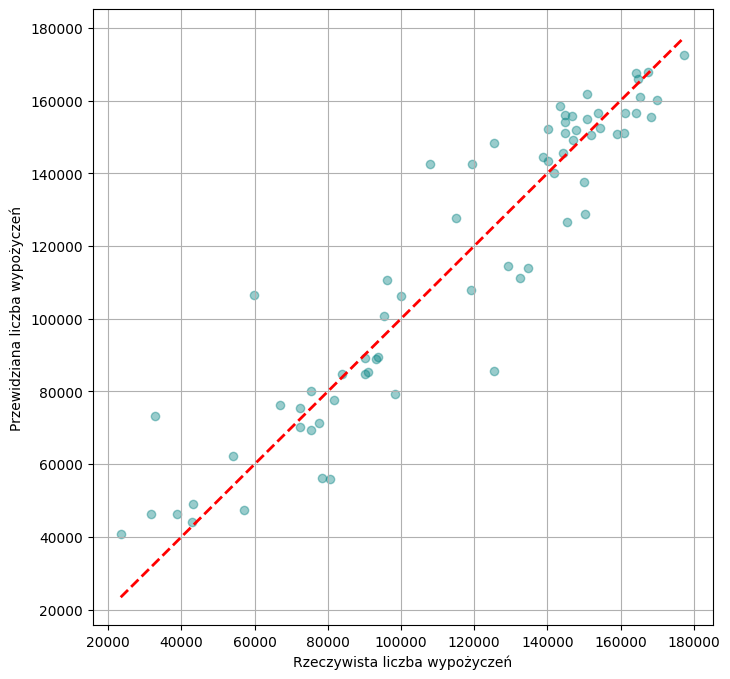

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal')

ideal_line = [y_test.min(), y_test.max()]
plt.plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=2)
plt.xlabel("Rzeczywista liczba wypożyczeń")
plt.ylabel("Przewidziana liczba wypożyczeń")
plt.grid(True)
plt.savefig('wynik.png')
plt.show()